# Stage 1: Missing & Invalid Data Handling
**Member:** **M1 — IT25101547**
**Assigned Preprocessing Technique:** Missing-value handling, invalid-value repair and schema integration
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 1 of 6 (sequential)
**Input:** `data/raw/us_perm_visas.csv` (298.6 MB, 374,362 rows x 154 columns)
**Output:** `results/outputs/stage1_missing_handled.parquet`

---
## 1. Explanation of the Technique

Real-world tabular data rarely arrives complete or valid. Common strategies:
1. **Column deletion** - drop features whose missing rate is so high that imputation would invent most of the values.
2. **Imputation** - fill gaps with a statistic learned from the training rows (median for skewed numeric data, an explicit `"Unknown"` category for categoricals).
3. **Missing-indicator flags** - add a 0/1 column marking imputed rows (useful only when *why* a value is missing is legitimately predictive).
4. **Invalid-value repair** - values that exist but are impossible (wrong units, impossible years, corrupted codes) are converted to `NaN` and then handled like missing data.

Imputation statistics must be computed on the **training rows only**, otherwise information from the test set leaks into the model. That is why this stage also creates the **stratified 80/20 train/test split**.

---
## 2. Justification for THIS Dataset Specifically

- **Schema drift.** The file merges several versions of the DOL ETA-9089 form, so the *same* field appears under different names (e.g. `country_of_citizenship` 5.5% missing and the misspelt `country_of_citzenship` 94.5% missing). Treating them as separate columns would invent missingness. We **coalesce** 5 such field groups first.
- **73 of 154 raw columns are > 60% missing**, many in exact blocks (36.1%, 59.8%, 76.3%) that correspond to form versions. We keep 32 core employer / job / wage / worker columns and apply a **60% drop threshold** (`refile`, `us_economic_sector` are dropped).
- **Invalid values:** wages are stored as text with commas and in 10 different unit spellings (`Year`, `yr`, `Hour`, `hr`, `Week`, `Bi-Weekly`, ...), states mix codes and full names (`CA` / `CALIFORNIA`), some SOC codes were corrupted into dates (`2021-11-01`), employer founding year has `0`, employer size reaches 263 million.
- **No missing-indicator flags:** missingness here mostly encodes the *form version*, which is a proxy for the decision year (and the denial rate drifts by year) - a flag would let models learn the year instead of the application.
- **Target framing:** `case_status` -> `denied` (1 = Denied, 0 = Certified / Certified-Expired); *Withdrawn* is an applicant choice, not a decision, so it is removed. 1,337 duplicate case IDs are reduced to their latest decision.
- **Leakage removal:** `case_received_date` (processing time is only known after the decision), case IDs and `application_type` (a form-version proxy) are dropped here. `decision_date` and `case_status` are kept **for EDA only** and are removed in Stage 6.

### Why this must be Stage 1
- Imputation and every later statistic need the train/test split, so the split is created here, before anything is learned from the data.
- Encoding (Stage 2) needs clean, valid category values (normalised states, validated SOC/NAICS codes), and outlier capping (Stage 3) needs wages in one unit (USD/year).

### Memory strategy for the 298 MB file
The CSV is read in 100,000-row chunks (`chunksize`), only the 32 needed columns are kept, numbers are parsed and stored as `float32`, and the output is written as Parquet. Set `DEV_SAMPLE = 0.10` in the config cell for a fast stratified ~37k-row development run.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 0: Load & integrate (chunked) — shared by S1 and group_pipeline
# ==============================================================================
# Only these 32 of the 154 raw columns are kept: core employer / job / wage / worker attributes
# plus the target, dates and IDs needed for EDA and de-duplication.
RAW_KEEP = [
    'case_status', 'decision_date', 'case_received_date', 'case_no', 'case_number', 'application_type',
    'employer_name', 'employer_state', 'employer_num_employees', 'employer_yr_estab', 'job_info_work_state',
    'pw_soc_code', 'pw_level_9089', 'pw_amount_9089', 'pw_unit_of_pay_9089', 'pw_source_name_9089',
    'wage_offer_from_9089', 'wage_offered_from_9089', 'wage_offer_unit_of_pay_9089', 'wage_offered_unit_of_pay_9089',
    'naics_2007_us_code', 'naics_us_code', 'naics_code',
    'country_of_citizenship', 'country_of_citzenship', 'class_of_admission',
    'foreign_worker_info_education', 'job_info_education', 'job_info_experience',
    'agent_firm_name', 'refile', 'us_economic_sector',
]
# The CSV merges several versions of the DOL form: the same field has different names per version.
COALESCE_MAP = {
    'case_id': ['case_no', 'case_number'],
    'country_of_citizenship': ['country_of_citizenship', 'country_of_citzenship'],
    'wage_offer_from': ['wage_offer_from_9089', 'wage_offered_from_9089'],
    'wage_offer_unit': ['wage_offer_unit_of_pay_9089', 'wage_offered_unit_of_pay_9089'],
    'naics_code': ['naics_2007_us_code', 'naics_us_code', 'naics_code'],
}
NUMERIC_TEXT_COLS = ['wage_offer_from', 'pw_amount_9089', 'employer_num_employees', 'employer_yr_estab']


def stage0_load_and_integrate(raw_csv=RAW_CSV, dev_sample=DEV_SAMPLE, chunksize=100_000, seed=SEED):
    """
    Reads the 298 MB CSV in 100k-row chunks (never all 154 columns at once):
    - profiles the missing % of all 154 raw columns,
    - keeps only RAW_KEEP, coalesces duplicate-named form fields,
    - parses comma-formatted numbers and ISO dates, normalises text case.
    Returns (dataframe, missingness table).
    """
    n_rows, notna, parts = 0, None, []
    for chunk in pd.read_csv(raw_csv, dtype=str, chunksize=chunksize):
        n_rows += len(chunk)
        counts = chunk.notna().sum()
        notna = counts if notna is None else notna + counts
        parts.append(chunk[RAW_KEEP])
    df = pd.concat(parts, ignore_index=True)
    missing = (1 - notna / n_rows).mul(100).rename('missing_pct_raw').to_frame()

    for new_col, old_cols in COALESCE_MAP.items():
        merged = df[old_cols[0]]
        for col in old_cols[1:]:
            merged = merged.combine_first(df[col])
        df = df.drop(columns=old_cols)
        df[new_col] = merged
        missing.loc[new_col, 'missing_pct_coalesced'] = merged.isna().mean() * 100

    for col in NUMERIC_TEXT_COLS:
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=False), errors='coerce')
    for col in ['decision_date', 'case_received_date']:
        df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors='coerce')
    for col in ['employer_state', 'job_info_work_state', 'country_of_citizenship', 'employer_name', 'agent_firm_name']:
        df[col] = df[col].str.strip().str.upper()

    if dev_sample:
        df = (df.groupby('case_status', group_keys=False)
                .sample(frac=dev_sample, random_state=seed)
                .sort_index())
    print(f'[Stage 0] Raw file: {n_rows:,} rows x {len(notna)} columns -> kept {df.shape[0]:,} rows x {df.shape[1]} columns')
    return df.reset_index(drop=True), missing

In [3]:
# ==============================================================================
# STAGE 1: Missing & Invalid Data Handling (M1)
# ==============================================================================
UNIT_TO_ANNUAL = {'year': 1, 'yr': 1, 'hour': 2080, 'hr': 2080, 'week': 52, 'wk': 52,
                  'bi-weekly': 26, 'bi': 26, 'month': 12, 'mth': 12}
WAGE_MIN, WAGE_MAX = 10_000, 1_000_000        # plausible annual wage range (USD)
YEAR_MIN, YEAR_MAX = 1800, REFERENCE_YEAR     # plausible employer founding years
MAX_EMPLOYEES = 2_500_000                     # larger than the biggest US employer -> invalid
MISSING_DROP_THRESHOLD = 0.60



def annualise_wage(amount, unit):
    """Convert a wage to USD/year. Missing unit -> infer from magnitude (<= 200 looks hourly). Implausible -> NaN."""
    multiplier = unit.str.strip().str.lower().map(UNIT_TO_ANNUAL)
    inferred = pd.Series(np.where(amount <= 200, 2080, 1), index=amount.index)
    annual = amount * multiplier.fillna(inferred)
    return annual.where(annual.between(WAGE_MIN, WAGE_MAX))


def stage1_missing_and_invalid_data(df, raw_missing=None, plot_dir=PLOT_DIR, show_plot=False):
    """
    1. Target: de-duplicate case IDs (keep latest decision), drop Withdrawn, create `denied`.
    2. Leakage: drop case_id, case_received_date, application_type.
    3. Split: stratified 80/20 -> `split` column. Every statistic from here on is fit on train rows only.
    4. Invalid values: annualise wages, normalise states, validate SOC / NAICS codes,
       implausible employer founding year / size -> NaN.
    5. Missing values: drop columns > 60% missing (train), numeric -> train median, categorical -> 'Unknown'.
    """
    d = df.copy()
    n_raw = len(d)
    d = d.sort_values('decision_date', kind='stable').drop_duplicates('case_id', keep='last').sort_index()
    n_dupes = n_raw - len(d)
    d = d[d['case_status'] != 'Withdrawn'].copy()
    d[TARGET] = (d['case_status'] == 'Denied').astype('int8')
    d = d.drop(columns=['case_id', 'case_received_date', 'application_type']).reset_index(drop=True)

    _, test_idx = train_test_split(d.index, test_size=TEST_SIZE, stratify=d[TARGET], random_state=SEED)
    d['split'] = 'train'
    d.loc[test_idx, 'split'] = 'test'
    train = d['split'].eq('train')

    # --- Invalid values ---
    d['wage_offer_annual'] = annualise_wage(d['wage_offer_from'], d['wage_offer_unit'].fillna(d['pw_unit_of_pay_9089']))
    d['pw_annual'] = annualise_wage(d['pw_amount_9089'], d['pw_unit_of_pay_9089'])
    d = d.drop(columns=['wage_offer_from', 'wage_offer_unit', 'pw_amount_9089', 'pw_unit_of_pay_9089'])
    for col in ['employer_state', 'job_info_work_state']:
        d[col] = d[col].map(STATE_LOOKUP)
    soc = d['pw_soc_code'].str.extract(r'^\s*(\d{2})-\d{4}')[0]
    d['soc_major_group'] = soc.where(soc.isin(VALID_SOC))
    naics = d['naics_code'].str.extract(r'^\s*(\d{2})')[0]
    d['naics_2digit'] = naics.where(naics.isin(VALID_NAICS))
    d = d.drop(columns=['pw_soc_code', 'naics_code'])
    d['employer_yr_estab'] = d['employer_yr_estab'].where(d['employer_yr_estab'].between(YEAR_MIN, YEAR_MAX))
    d['employer_num_employees'] = d['employer_num_employees'].where(
        d['employer_num_employees'].between(1, MAX_EMPLOYEES))

    # --- Missing values ---
    features = [c for c in d.columns if c not in NON_FEATURE_COLS]
    miss_train = d.loc[train, features].isna().mean()
    dropped = miss_train[miss_train > MISSING_DROP_THRESHOLD].index.tolist()
    d = d.drop(columns=dropped)
    features = [c for c in features if c not in dropped]
    numeric = [c for c in features if pd.api.types.is_numeric_dtype(d[c])]
    categorical = [c for c in features if c not in numeric]
    medians = d.loc[train, numeric].median()
    missing_before = d[features].isna().mean() * 100
    d[numeric] = d[numeric].fillna(medians).astype('float32')
    d[categorical] = d[categorical].fillna('Unknown')

    d = d[EDA_ONLY_COLS + sorted(features) + [TARGET, 'split']]
    print(f'[Stage 1] removed {n_dupes:,} duplicate case IDs, dropped Withdrawn -> {len(d):,} rows; '
          f'dropped >60%-missing columns {dropped}; imputed medians {medians.round(0).to_dict()}')

    if plot_dir:
        fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1.25, 1]})
        plt.subplots_adjust(wspace=0.25)
        if raw_missing is not None:
            raw = raw_missing['missing_pct_raw'].dropna().sort_values()
            colors = np.where(raw > MISSING_DROP_THRESHOLD * 100, '#e74c3c', '#27ae60')
            axes[0].bar(range(len(raw)), raw.values, color=colors, width=1.0)
            axes[0].axhline(MISSING_DROP_THRESHOLD * 100, color='black', linestyle='--', linewidth=1)
            axes[0].text(2, MISSING_DROP_THRESHOLD * 100 + 2, '60% drop threshold', fontsize=9)
            for level in (36.1, 59.8, 76.3):
                axes[0].axhline(level, color='#7f8c8d', linestyle=':', linewidth=0.8)
                axes[0].text(len(raw) - 1, level + 1, f'{level}% block (form version)', fontsize=8, ha='right', color='#555')
            axes[0].set_title(f'Missing % of all {len(raw)} raw columns (sorted)\n'
                              f'{(raw > 60).sum()} columns > 60% missing (red)', fontweight='bold')
            axes[0].set_xlabel('Raw columns')
            axes[0].set_ylabel('Missing (%)')
            co = raw_missing.dropna(subset=['missing_pct_coalesced'])
            best_single = [raw_missing.loc[COALESCE_MAP[c], 'missing_pct_raw'].min() for c in co.index]
            x = np.arange(len(co))
            b1 = axes[1].bar(x - 0.2, best_single, 0.4, label='Best single raw column', color='#e67e22')
            b2 = axes[1].bar(x + 0.2, co['missing_pct_coalesced'], 0.4, label='After coalescing form versions', color='#2980b9')
            axes[1].bar_label(b1, fmt='%.1f%%', fontsize=8, padding=2)
            axes[1].bar_label(b2, fmt='%.2f%%', fontsize=8, padding=2)
            axes[1].set_xticks(x, co.index, rotation=20)
            axes[1].set_ylabel('Missing (%)')
            axes[1].set_title('Coalescing duplicate-named form fields\n(remaining NaNs imputed: median / "Unknown")',
                              fontweight='bold')
            axes[1].legend()
            axes[1].margins(y=0.15)
        n_over = int((raw_missing['missing_pct_raw'] > MISSING_DROP_THRESHOLD * 100).sum()) if raw_missing is not None else 0
        plt.suptitle(f'm1: Missing & Invalid Data - {n_over} raw columns are > 60% missing, 5 fields are merged',
                     fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m1_missingness_before_after.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()
    return d

In [4]:
# 1. Stage 0: chunked load + schema integration
df_0, raw_missing = stage0_load_and_integrate()
raw_missing.round(2).to_csv(os.path.join(OUT_DIR, 'raw_missingness.csv'))
df_0.head()

[Stage 0] Raw file: 374,362 rows x 154 columns -> kept 374,362 rows x 26 columns


,case_status,decision_date,case_received_date,application_type,employer_name,employer_state,employer_num_employees,employer_yr_estab,job_info_work_state,pw_soc_code,...,job_info_education,job_info_experience,agent_firm_name,refile,us_economic_sector,case_id,country_of_citizenship,wage_offer_from,wage_offer_unit,naics_code
0,Certified,2012-02-01,NaT,PERM,NETSOFT USA INC.,NY,NaN,NaN,NY,15-1031.00,...,NaN,NaN,NaN,NaN,IT,A-07323-97014,ARMENIA,75629.00,yr,541512
1,Denied,2011-12-21,NaT,PERM,PINNACLE ENVIRONEMNTAL CORP,NY,NaN,NaN,NY,47-4041.00,...,NaN,NaN,NaN,NaN,Other Economic Sector,A-07332-99439,POLAND,37024.00,yr,562211
2,Certified,2011-12-01,NaT,PERM,"SCHNABEL ENGINEERING, INC.",VA,NaN,NaN,MD,17-2051.00,...,NaN,NaN,NaN,NaN,Aerospace,A-07333-99643,INDIA,47923.00,yr,541330
3,Certified,2011-12-01,NaT,PERM,EBENEZER MISSION CHURCH,NY,NaN,NaN,NY,43-4071.00,...,NaN,NaN,NaN,NaN,Other Economic Sector,A-07339-01930,SOUTH KOREA,10.97,hr,813110
4,Certified,2012-01-26,NaT,PERM,ALBANY INTERNATIONAL CORP.,NY,NaN,NaN,NY,41-9031.00,...,NaN,NaN,NaN,NaN,Advanced Mfg,A-07345-03565,CANADA,100000.00,yr,333291


[Stage 1] removed 1,337 duplicate case IDs, dropped Withdrawn -> 354,849 rows; dropped >60%-missing columns ['refile', 'us_economic_sector']; imputed medians {'employer_num_employees': 1269.0, 'employer_yr_estab': 1996.0, 'wage_offer_annual': 91562.0, 'pw_annual': 86278.0}


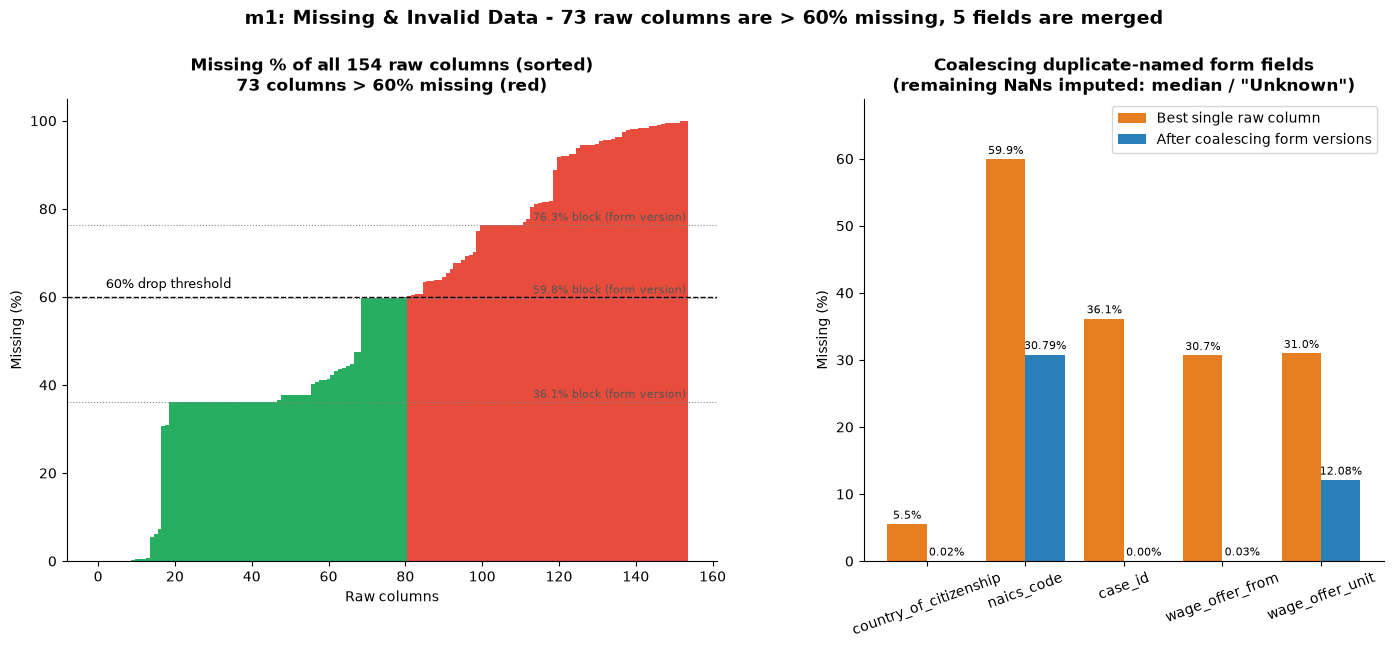

Saved Stage 1 output: 354,849 rows x 21 columns


In [5]:
# 2. Stage 1: missing & invalid data handling (+ EDA plot m1)
df_1 = stage1_missing_and_invalid_data(df_0, raw_missing, show_plot=True)
df_1.to_parquet(os.path.join(OUT_DIR, 'stage1_missing_handled.parquet'), index=False)
print(f'Saved Stage 1 output: {df_1.shape[0]:,} rows x {df_1.shape[1]} columns')

In [6]:
# 3. Verification ("done when" checks)
features = [c for c in df_1.columns if c not in NON_FEATURE_COLS]
assert df_1[features].isna().sum().sum() == 0, 'NaNs remain in feature columns'
assert not set(LEAKAGE_COLS) & set(df_1.columns), 'a leakage column survived'
rates = df_1.groupby('split')[TARGET].mean() * 100
assert abs(rates['train'] - rates['test']) < 0.2, 'split is not stratified'
print(f'Rows: {len(df_1):,} | denied: {df_1[TARGET].sum():,} ({df_1[TARGET].mean():.2%})')
print('Rows per split:', df_1['split'].value_counts().to_dict(), '| denied % per split:', rates.round(3).to_dict())
print('All Stage 1 checks passed.')

Rows: 354,849 | denied: 24,524 (6.91%)
Rows per split: {'train': 283879, 'test': 70970} | denied % per split: {'test': 6.911, 'train': 6.911}
All Stage 1 checks passed.


## 3. EDA Interpretation & Findings

1. **Missingness is structural, not random.** The sorted bar chart shows plateaus at exactly 36.1%, 59.8% and 76.3%: whole groups of columns that only exist on one version of the form. 73 of 154 raw columns exceed the 60% threshold.
2. **Coalescing recovers almost everything.** Citizenship drops from 5.5% to 0.02% missing, the offered wage from 30.7% to 0.03%, and NAICS industry codes from 59.9% to 30.8% (the remainder becomes `"Unknown"`).
3. **Invalid values:** after annualising wages, only 0.08% of offered wages and 1.08% of prevailing wages fall outside the plausible USD 10k-1M range and are re-imputed (train medians: offered USD 91,562, prevailing USD 86,278, employer size 1,269, founding year 1996).
4. **A signal worth reporting:** the prevailing wage is missing for **9.3% of denied** applications but only ~0.4% of approved ones. This is information on the form at filing time (an incomplete application), so it is *not* post-decision leakage - but it is a strong shortcut; teammates should test models with and without the `pwsrc_*` columns.
5. **Result:** 354,849 applications (24,524 denied = **6.91%**), split into 283,879 train / 70,970 test with an identical denial rate - an "always approve" model would already score 93.1% accuracy, so accuracy alone is not a valid metric for this project.